In [2]:
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten,Dense
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
import os

# Ensure 'path' is correctly defined from the previous kagglehub download
# Example: path = '/kaggle/input/chest-xray-pneumonia'
# If path is not defined, you might need to run the kagglehub download cell again.

base_dir = os.path.join(path, 'chest_xray')
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
# Define data directories using the existing 'base_dir'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

# Check if directories exist
print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Validation directory exists: {os.path.exists(val_dir)}")

Train directory exists: True
Validation directory exists: True


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
print("Number of training images:", train_generator.samples)
print("Number of validation images:", validation_generator.samples)

Number of training images: 5216
Number of validation images: 16


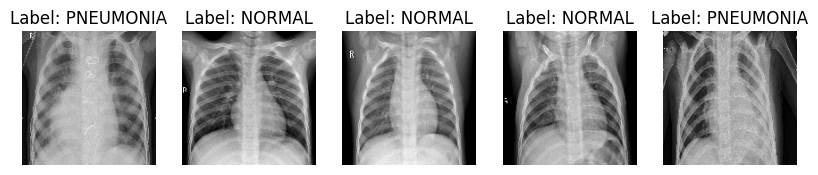

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(10,6))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title("Label: " + ("PNEUMONIA" if labels[i]==1 else "NORMAL"))
    plt.axis("off")

plt.show()

In [ ]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)), # Changed input_shape to 3 channels
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Changed loss to binary_crossentropy

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 418ms/step - accuracy: 0.7751 - loss: 0.5280 - val_accuracy: 0.7500 - val_loss: 0.5732
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 289ms/step - accuracy: 0.9374 - loss: 0.1631 - val_accuracy: 0.7500 - val_loss: 0.5368
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 46s 281ms/step - accuracy: 0.9532 - loss: 0.1375 - val_accuracy: 0.7500 - val_loss: 0.9271
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 287ms/step - accuracy: 0.9546 - loss: 0.1201 - val_accuracy: 0.8750 - val_loss: 0.1933
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 296ms/step - accuracy: 0.9604 - loss: 0.1038 - val_accuracy: 0.8125 - val_loss: 0.3314
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 305ms/step - accuracy: 0.9713 - loss: 0.0856 - val_accuracy: 0.8125 - val_loss: 0.3282
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 304ms/step - accuracy: 0.9717 - loss: 0.0807 - val_accuracy: 0.8125 - val_loss: 0.6182
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 331ms/step - accuracy: 0.9779 - loss: 0

In [ ]:
test_loss,test_acc=model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")
print(f"Test loss:{test_loss}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5225 - loss: 2.5843
Test accuracy: 0.7564102411270142
Test loss:1.4210915565490723


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step


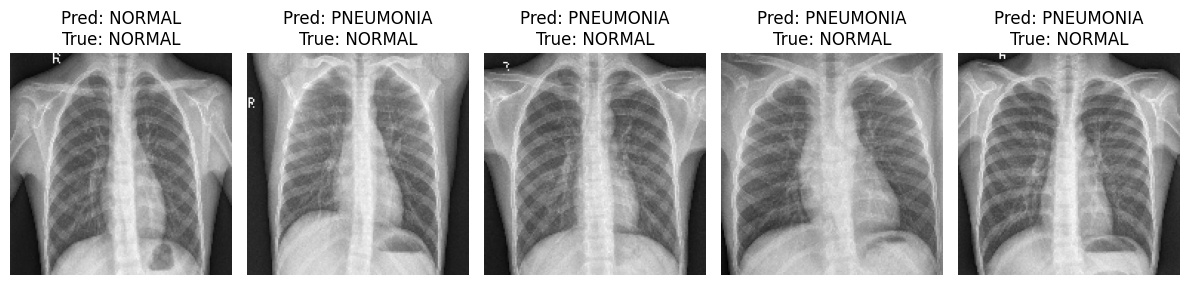

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Collect 5 samples from test_generator for prediction and display
test_images_sample = []
test_labels_sample = []

# Reset test_generator to ensure we get samples from the beginning
test_generator.reset()

# Get the first 5 images and labels from the test generator
for _ in range(5):
    img_batch, label_batch = next(test_generator)
    test_images_sample.append(img_batch[0]) # img_batch is (1, H, W, C), take [0] to get (H, W, C)
    test_labels_sample.append(label_batch[0]) # label_batch is (1,), take [0] to get scalar label

x_test_sample = np.array(test_images_sample)
y_test_sample = np.array(test_labels_sample)

# Make predictions on the collected samples
predictions = model.predict(x_test_sample)

# For binary classification with sigmoid output, convert probabilities to binary classes
predicted_classes = (predictions > 0.5).astype(int).flatten()
actual_classes = y_test_sample.astype(int)

# Display Predictions
plt.figure(figsize=(12, 8))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test_sample[i]) # Images are already in the correct format (H, W, C)
    true_label = "PNEUMONIA" if actual_classes[i] == 1 else "NORMAL"
    pred_label = "PNEUMONIA" if predicted_classes[i] == 1 else "NORMAL"
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Reset the test generator to ensure predictions are made on the full, ordered test set
test_generator.reset()

# Get true labels for the entire test set
y_true = test_generator.classes

# Get predictions for the entire test set
y_pred_raw = model.predict(test_generator, steps=test_generator.samples)

# Convert probabilities to binary class labels (0 or 1)
y_pred_classes = (y_pred_raw > 0.5).astype(int).flatten()

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Generate Classification Report
# test_generator.class_indices can be used to get class names
class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred_classes, target_names=class_names)
print("\nClassification Report:")
print(report)

624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step
Confusion Matrix:
[[ 84 150]
 [  2 388]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.36      0.53       234
   PNEUMONIA       0.72      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.85      0.68      0.68       624
weighted avg       0.82      0.76      0.72       624



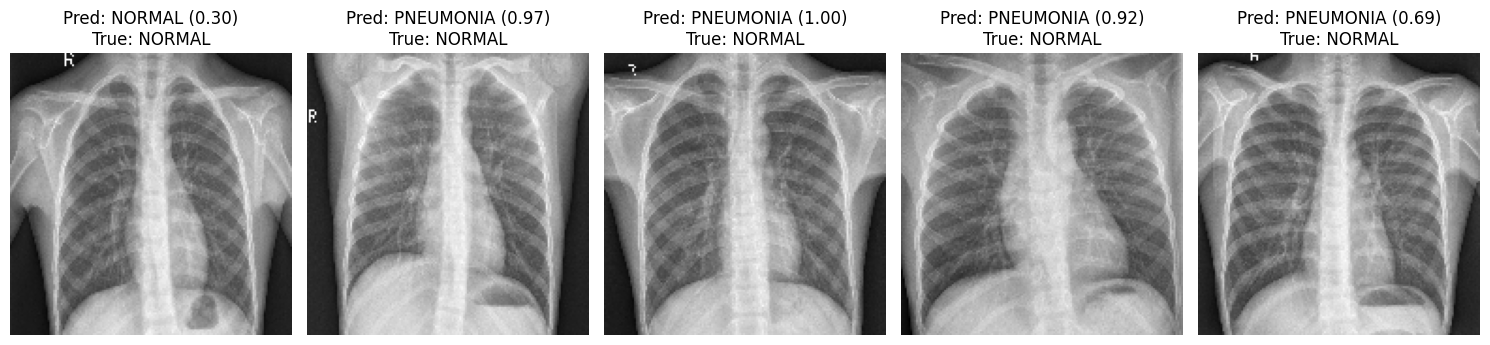

In [ ]:
import matplotlib.pyplot as plt

# Display the same 5 samples from the previous cell with probabilities
plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test_sample[i])

    true_label_text = "PNEUMONIA" if actual_classes[i] == 1 else "NORMAL"
    pred_label_text = "PNEUMONIA" if predicted_classes[i] == 1 else "NORMAL"
    probability = predictions[i][0] # Get the probability for the positive class

    plt.title(f"Pred: {pred_label_text} ({probability:.2f})\nTrue: {true_label_text}")
    plt.axis("off")

plt.tight_layout()
plt.show()